# Сравнение стратегий задачи о назначениях



In [1]:
import numpy as np
from scipy.optimize import linear_sum_assignment
import time
import matplotlib.pyplot as plt


## Генерация данных

Матрица **C** (в коде: `A`): элемент `cᵢⱼ` — потенциальная прибыль группы `i` в период `j`.

Вектор **χ** длиной `n`: коэффициент уязвимости группы `i`, `0 < χᵢ < 1`.

Матрица **B** (формула из документа, §3, индексация с 1):

```
bᵢⱼ = (1 − χᵢ) · Σ_{t=j}^{n} cᵢₜ,   i, j = 1, …, n
```

В коде (0-индексация): `B[i][j] = (1 - chi[i]) * sum(A[i][t] for t in range(j, n))`

In [2]:
def build_B_matrix(A, chi):
    """Формула документа (§3): bᵢⱼ = (1 − χᵢ) · Σ_{t=j}^{n} cᵢₜ  (индексация с 1).
    В коде (0-индексация): B[i][j] = (1 - chi[i]) * sum(A[i][t] for t in range(j, n))."""
    n = A.shape[0]
    B = np.zeros((n, n))
    for i in range(n):
        suffix = np.zeros(n)
        suffix[n - 1] = A[i][n - 1]
        for t in range(n - 2, -1, -1):
            suffix[t] = suffix[t + 1] + A[i][t]
        for j in range(n):
            B[i][j] = (1 - chi[i]) * suffix[j]
    return B

def calculate_total_profit(A, chi, B, schedule):
    """Целевая функция: базовая прибыль + бонус за защиту."""
    base = np.sum(chi[:, np.newaxis] * A)
    bonus = sum(B[schedule[j]][j] for j in range(A.shape[0]))
    return base + bonus

def generate_A_descending(n, low=1, high=10):
    A = np.zeros((n, n))
    for i in range(n):
        row = np.random.uniform(low, high, n)
        row.sort()
        A[i] = row[::-1]
    return A

def generate_A_ascending(n, low=1, high=10):
    A = np.zeros((n, n))
    for i in range(n):
        row = np.random.uniform(low, high, n)
        row.sort()
        A[i] = row
    return A

def generate_A_random(n, low=1, high=10):
    return np.random.uniform(low, high, (n, n))

def generate_chi(n, low=0.3, high=0.8):
    return np.random.uniform(low, high, n)


## Стратегии

Все стратегии принимают **полную матрицу A** и вектор **χ**.
Это соответствует экспериментальной постановке из документа:
матрица сгенерирована заранее, стратегии соревнуются по итоговой прибыли.

- **Жадная** — на каждом шаге выбирает `argmax B[i][j]` среди свободных групп.
  Требует полного знания B (и, следовательно, всей A). Описана в документе как
  основная эвристика для сравнения.
- **χ-стратегия** — сортировка по возрастанию χᵢ. Решение не зависит от A.
- **Венгерский алгоритм** — оптимальное назначение на полной матрице B.
  Используется как  эталон.
- **Гибрид-1 / Гибрид-2** — чередование жадного и χ-шагов.
- **Ансамбль-жадный / Ансамбль-χ** — несколько агентов с случайной выборкой кандидатов;
  побеждает агент с наибольшей итоговой прибылью.

In [3]:
def greedy_strategy(A, chi):
    """argmax B[i][j] на каждом шаге. Требует знания полной матрицы A."""
    B = build_B_matrix(A, chi)
    n = A.shape[0]
    used = set()
    schedule = []
    for j in range(n):
        available = [i for i in range(n) if i not in used]
        best_i = max(available, key=lambda i: B[i][j])
        schedule.append(best_i)
        used.add(best_i)
    return schedule

def chi_strategy(A, chi):
    """Сортировка по возрастанию chi. Матрица A не используется."""
    return list(np.argsort(chi))

def hungarian_strategy(A, chi):
    """Оптимальное решение на полной B (пост-фактум эталон)."""
    B = build_B_matrix(A, chi)
    row_ind, col_ind = linear_sum_assignment(-B)
    schedule = [-1] * A.shape[0]
    for i, j in zip(row_ind, col_ind):
        schedule[j] = i
    return schedule

def hybrid_strategy(A, chi):
    """Чётные шаги: min chi; нечётные: argmax B[i][j]."""
    B = build_B_matrix(A, chi)
    n = A.shape[0]
    used = set()
    schedule = []
    for j in range(n):
        available = [i for i in range(n) if i not in used]
        if j % 2 == 0:
            best_i = min(available, key=lambda i: chi[i])
        else:
            best_i = max(available, key=lambda i: B[i][j])
        schedule.append(best_i)
        used.add(best_i)
    return schedule

def hybrid_strategy2(A, chi):
    """Чётные шаги: argmax B[i][j]; нечётные: min chi."""
    B = build_B_matrix(A, chi)
    n = A.shape[0]
    used = set()
    schedule = []
    for j in range(n):
        available = [i for i in range(n) if i not in used]
        if j % 2 == 0:
            best_i = max(available, key=lambda i: B[i][j])
        else:
            best_i = min(available, key=lambda i: chi[i])
        schedule.append(best_i)
        used.add(best_i)
    return schedule


In [4]:
# greedy_strategy выбирает argmax B[i][j] среди ВСЕХ свободных групп — результат всегда один и тот же.
# ensemble_strategy запускает num_models копий жадного, но каждый видит только случайные ss кандидатов
# разные агенты строят разные расписания → берём лучшее (аналог Random Forest с деревьями).

def ensemble_strategy(A, chi, num_models=10, sample_size=None):
    B  = build_B_matrix(A, chi)
    n  = A.shape[0]
    ss = sample_size if sample_size is not None else max(1, n // 3)

    schedules = [[-1] * n for agent in range(num_models)]
    used      = [set()    for agent in range(num_models)]
    rngs      = [np.random.default_rng(seed=agent) for agent in range(num_models)]

    for j in range(n):
        for agent in range(num_models):

            # собираем все свободные группы этого агента
            available = []
            for i in range(n):
                if i not in used[agent]:
                    available.append(i)

            # случайно берём ss из них — источник разнообразия между агентами
            k = min(ss, len(available))
            candidates = rngs[agent].choice(available, size=k, replace=False)

            # жадный выбор — argmax B[i][j], но только среди candidates
            best_i = candidates[0]
            for i in candidates:
                if B[i][j] > B[best_i][j]:
                    best_i = i

            schedules[agent][j] = best_i
            used[agent].add(best_i)

    # выбирается — агент с максимальной итоговой прибылью
    best_agent = 0
    for agent in range(1, num_models):
        if calculate_total_profit(A, chi, B, schedules[agent]) > \
           calculate_total_profit(A, chi, B, schedules[best_agent]):
            best_agent = agent

    return schedules[best_agent]

def ensemble_chi_strategy(A, chi, num_models=10, sample_size=None):
    B  = build_B_matrix(A, chi)
    n  = len(chi)
    ss = sample_size if sample_size is not None else max(1, n // 3)

    schedules = [[-1] * n for agent in range(num_models)]
    used      = [set()    for agent in range(num_models)]
    rngs      = [np.random.default_rng(seed=agent) for agent in range(num_models)]

    for j in range(n):
        for agent in range(num_models):

            available = []
            for i in range(n):
                if i not in used[agent]:
                    available.append(i)

            k = min(ss, len(available))
            candidates = rngs[agent].choice(available, size=k, replace=False)

            # жадный выбор — min chi[i], но только среди candidates
            best_i = candidates[0]
            for i in candidates:
                if chi[i] < chi[best_i]:
                    best_i = i

            schedules[agent][j] = best_i
            used[agent].add(best_i)

    best_agent = 0
    for agent in range(1, num_models):
        if calculate_total_profit(A, chi, B, schedules[agent]) > \
           calculate_total_profit(A, chi, B, schedules[best_agent]):
            best_agent = agent

    return schedules[best_agent]


In [5]:
def run_single_experiment(A_generator, n=10, a_low=1, a_high=10,
                          chi_low=0.3, chi_high=0.8,
                          num_models=10, sample_size=None):
    A   = A_generator(n, a_low, a_high)
    chi = generate_chi(n, chi_low, chi_high)
    B   = build_B_matrix(A, chi)
    results = {}
    strategies = [
        ('greedy',       lambda: greedy_strategy(A, chi)),
        ('chi',          lambda: chi_strategy(A, chi)),
        ('hungarian',    lambda: hungarian_strategy(A, chi)),
        ('hybrid',       lambda: hybrid_strategy(A, chi)),
        ('hybrid2',      lambda: hybrid_strategy2(A, chi)),
        ('ensemble',     lambda: ensemble_strategy(A, chi, num_models, sample_size)),
        ('ensemble_chi', lambda: ensemble_chi_strategy(A, chi, num_models, sample_size)),
    ]
    for name, fn in strategies:
        t0    = time.time()
        sched = fn()
        t1    = time.time()
        results[name] = {
            'schedule': sched,
            'time':     t1 - t0,
            'profit':   calculate_total_profit(A, chi, B, sched),
        }
    return results

def run_series(A_generator, series_name, num_experiments=30, n=10,
               num_models=10, sample_size=None):
    SEP = '=' * 70
    print('\n' + SEP)
    print('Серия:', series_name)
    print(SEP)

    strategies = ['greedy', 'chi', 'hungarian', 'hybrid', 'hybrid2',
                  'ensemble', 'ensemble_chi']
    stats = {s: {'profits': [], 'times': []} for s in strategies}

    for _ in range(num_experiments):
        res = run_single_experiment(A_generator, n=n,
                                    num_models=num_models,
                                    sample_size=sample_size)
        for s in strategies:
            stats[s]['profits'].append(res[s]['profit'])
            stats[s]['times'].append(res[s]['time'])

    max_avg = np.mean(stats['hungarian']['profits'])
    min_avg = np.mean(stats['chi']['profits'])
    gap     = max(max_avg - min_avg, 1e-9)

    hdr = '{:<14} {:<12} {:<10} {:<12} {:<12} {:<12}'.format(
        'Стратегия', 'Ср.прибыль', 'Ср.время', 'Отн.потери',
        'Норм.эфф.', 'Худш.потери')
    print(hdr)
    print('-' * 74)

    for s in strategies:
        avg_p      = np.mean(stats[s]['profits'])
        avg_t      = np.mean(stats[s]['times'])
        loss       = 0.0 if s == 'hungarian' else (max_avg - avg_p) / max_avg * 100
        eff        = (avg_p - min_avg) / gap * 100
        worst_loss = (max_avg - min(stats[s]['profits'])) / max_avg * 100
        stats[s]['avg_profit'] = avg_p
        stats[s]['loss']       = loss
        stats[s]['norm_eff']   = eff
        stats[s]['worst_loss'] = worst_loss
        print('{:<14} {:>10.2f} {:>8.4f}s {:>10.2f}% {:>10.1f}% {:>10.2f}%'.format(
              s, avg_p, avg_t, loss, eff, worst_loss))

    print('\n  Верхняя граница (Венгерский):', round(max_avg, 2))
    print('  Нижняя граница (chi-стратегия):', round(min_avg, 2))
    return stats


## Запуск экспериментов

Три серии по `NUM_EXP` испытаний для разных типов матрицы A.

In [6]:
N           = 50   # размер матрицы (n×n групп и периодов)
NUM_EXP     = 50   # количество независимых экспериментов в каждой серии
NUM_MODELS  = 20   # количество агентов в ансамбле (аналог числа деревьев в Random Forest)
SAMPLE_SIZE = N // 3  # размер случайной выборки кандидатов для каждого агента

series = [
    ('Убывание',    generate_A_descending),
    ('Возрастание', generate_A_ascending),
    ('Случайная',   generate_A_random),
]

all_stats = {}
for series_name, generator in series:
    all_stats[series_name] = run_series(
        generator, series_name, NUM_EXP, n=N,
        num_models=NUM_MODELS, sample_size=SAMPLE_SIZE
    )



Серия: Убывание


Стратегия      Ср.прибыль   Ср.время   Отн.потери   Норм.эфф.    Худш.потери 
--------------------------------------------------------------------------
greedy           10451.57   0.0020s       0.13%       45.1%       4.74%
chi              10440.55   0.0000s       0.23%        0.0%       5.03%
hungarian        10464.97   0.0018s       0.00%      100.0%       4.58%
hybrid           10449.31   0.0021s       0.15%       35.9%       4.88%
hybrid2          10449.53   0.0020s       0.15%       36.8%       4.87%
ensemble         10452.74   0.0222s       0.12%       49.9%       4.71%
ensemble_chi     10440.31   0.0200s       0.24%       -1.0%       4.98%

  Верхняя граница (Венгерский): 10464.97
  Нижняя граница (chi-стратегия): 10440.55

Серия: Возрастание


Стратегия      Ср.прибыль   Ср.время   Отн.потери   Норм.эфф.    Худш.потери 
--------------------------------------------------------------------------
greedy           12111.84   0.0019s       0.15%       41.5%       2.99%
chi              12099.27   0.0000s       0.25%        0.0%       3.10%
hungarian        12129.58   0.0017s       0.00%      100.0%       2.76%
hybrid           12106.31   0.0020s       0.19%       23.2%       3.03%
hybrid2          12106.64   0.0019s       0.19%       24.3%       3.02%
ensemble         12114.48   0.0213s       0.12%       50.2%       2.95%
ensemble_chi     12102.98   0.0184s       0.22%       12.2%       3.08%

  Верхняя граница (Венгерский): 12129.58
  Нижняя граница (chi-стратегия): 12099.27

Серия: Случайная


Стратегия      Ср.прибыль   Ср.время   Отн.потери   Норм.эфф.    Худш.потери 
--------------------------------------------------------------------------
greedy           11311.21   0.0023s       0.76%       23.1%       5.11%
chi              11285.23   0.0000s       0.99%        0.0%       5.49%
hungarian        11397.54   0.0019s       0.00%      100.0%       4.24%
hybrid           11299.92   0.0020s       0.86%       13.1%       5.32%
hybrid2          11299.77   0.0019s       0.86%       12.9%       5.38%
ensemble         11320.34   0.0234s       0.68%       31.3%       5.13%
ensemble_chi     11298.96   0.0191s       0.86%       12.2%       5.26%

  Верхняя граница (Венгерский): 11397.54
  Нижняя граница (chi-стратегия): 11285.23


## Визуализация результатов

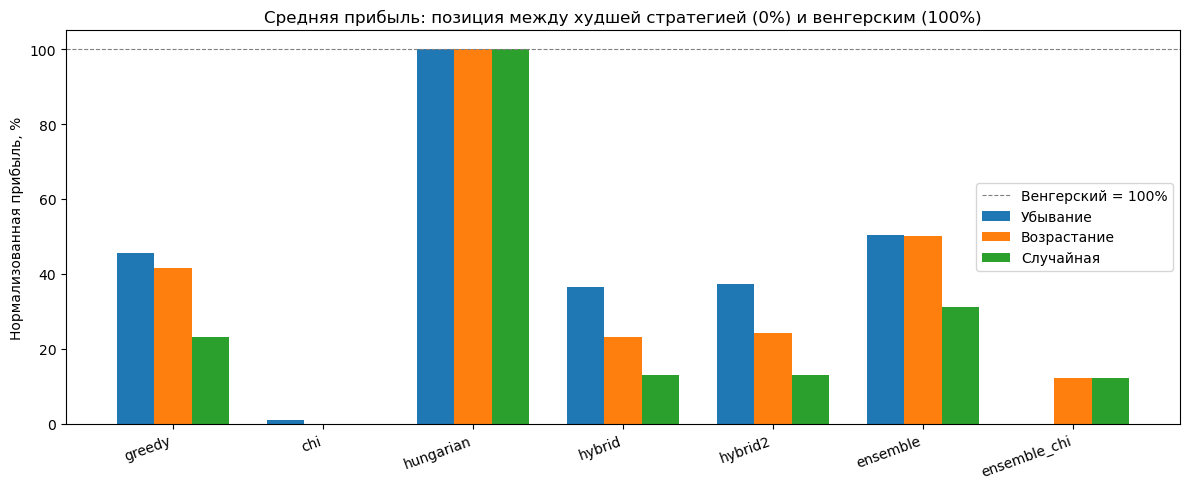

In [7]:
# Нормализованная прибыль относительно венгерского алгоритма:
#   score(s) = (avg(s) - min_серии) / (avg(hungarian) - min_серии) * 100%
# Венгерский = 100% (верхняя граница, всегда).
# Фактически худшая стратегия в серии = 0% (нижняя граница, любая).
# χ-стратегия не фиксирована на 0 — она может оказаться выше если не худшая.
strat_labels = ['greedy', 'chi', 'hungarian', 'hybrid', 'hybrid2',
                'ensemble', 'ensemble_chi']
series_names = list(all_stats.keys())
x = np.arange(len(strat_labels))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 5))
for k, sname in enumerate(series_names):
    avgs       = {s: all_stats[sname][s]['avg_profit'] for s in strat_labels}
    hun_avg    = avgs['hungarian']
    series_min = min(avgs.values())
    gap        = hun_avg - series_min
    vals = [(avgs[s] - series_min) / gap * 100 if gap > 1e-9 else 0.0
            for s in strat_labels]
    ax.bar(x + k * width, vals, width, label=sname)

ax.axhline(100, color='grey', linewidth=0.8, linestyle='--', label='Венгерский = 100%')
ax.set_xticks(x + width)
ax.set_xticklabels(strat_labels, rotation=20, ha='right')
ax.set_ylabel('Нормализованная прибыль, %')
ax.set_title('Средняя прибыль: позиция между худшей стратегией (0%) и венгерским (100%)')
ax.legend()
plt.tight_layout()
plt.show()


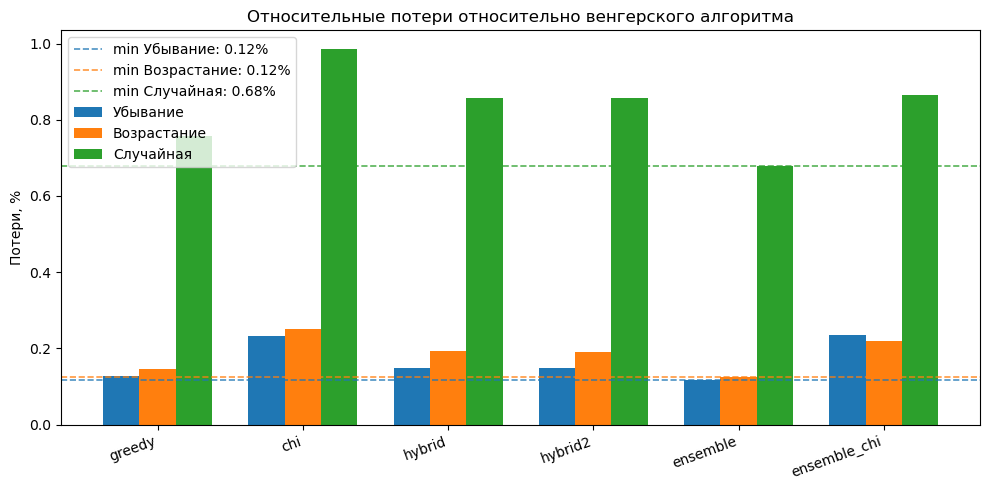

In [8]:
# Относительные потери (%) относительно венгерского алгоритма
non_hun = [s for s in strat_labels if s != 'hungarian']
x2 = np.arange(len(non_hun))

fig, ax = plt.subplots(figsize=(10, 5))
bar_colors = []
for k, sname in enumerate(series_names):
    vals = [all_stats[sname][s]['loss'] for s in non_hun]
    bars = ax.bar(x2 + k * width, vals, width, label=sname)
    bar_colors.append(bars[0].get_facecolor())

# Горизонтальная линия на уровне минимальных потерь для каждой серии
for k, sname in enumerate(series_names):
    vals = [all_stats[sname][s]['loss'] for s in non_hun]
    min_val = min(vals)
    ax.axhline(min_val, color=bar_colors[k], linestyle='--', linewidth=1.2,
               alpha=0.8, label=f'min {sname}: {min_val:.2f}%')

ax.set_xticks(x2 + width)
ax.set_xticklabels(non_hun, rotation=20, ha='right')
ax.set_ylabel('Потери, %')
ax.set_title('Относительные потери относительно венгерского алгоритма')
ax.legend()
plt.tight_layout()
plt.show()


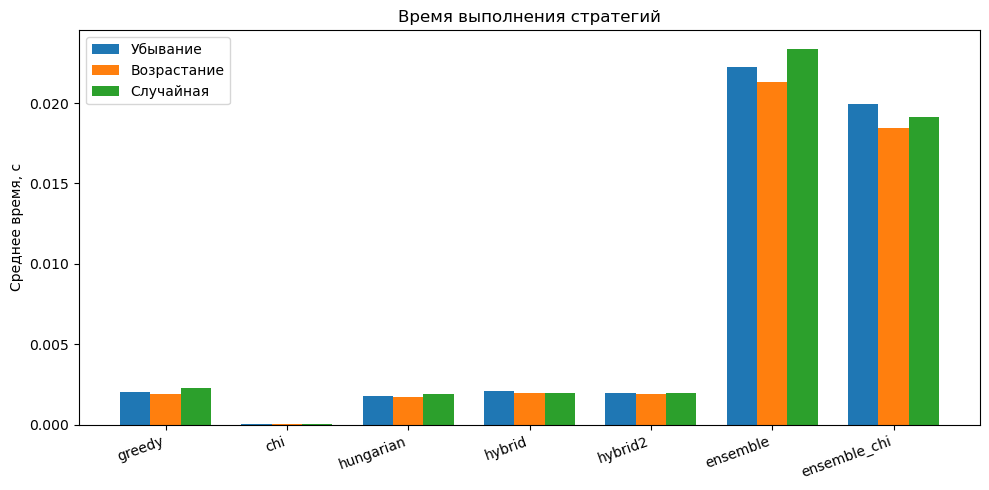

In [9]:
# Среднее время выполнения
fig, ax = plt.subplots(figsize=(10, 5))
for k, sname in enumerate(series_names):
    vals = [np.mean(all_stats[sname][s]['times']) for s in strat_labels]
    ax.bar(x + k * width, vals, width, label=sname)
ax.set_xticks(x + width)
ax.set_xticklabels(strat_labels, rotation=20, ha='right')
ax.set_ylabel('Среднее время, с')
ax.set_title('Время выполнения стратегий')
ax.legend()
plt.tight_layout()
plt.show()
